 # 01 — Разведочный анализ данных (EDA)

 **Задача:** хакатон Альфа-Банка, ранжирование кредитных предложений
 по метрике NDCG@5. Для каждого `request_id` дан список вариантов
 `variant_no`, требуется отсортировать их так, чтобы реально купленное
 предложение (`is_deal=1`) оказалось как можно выше в топе.

 **Цели этого ноутбука:**
 1. Понять схему всех трёх таблиц (`train`, `test`, `features`).
 2. Изучить распределение таргета, число вариантов на запрос.
 3. Проверить временной разрез — выбрать схему валидации (GroupKFold / time-based).
 4. Найти потенциальный position bias по `variant_no`.
 5. Оценить drift между train и test (adversarial validation).
 6. Сформировать список наблюдений для построения пайплайна моделирования.


In [1]:
import json
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings("ignore", category=FutureWarning)

DATA_DIR = Path("../data")
OUT_SUMMARY = DATA_DIR / "eda_summary.json"

TARGET = "is_deal"
REQUEST_ID = "request_id"
VARIANT_ID = "variant_no"

# Глобальные настройки отображения
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 200)
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["figure.dpi"] = 100

SUMMARY: dict[str, object] = {}
print("Окружение настроено. Текущая директория:", Path.cwd())

Окружение настроено. Текущая директория: d:\prog\ml\alfa_cred\alfa\notebooks


## 1. Загрузка датасетов и общая шейп-сводка

In [2]:
df_train = pd.read_parquet(DATA_DIR / "train_dataset_small.pq")
df_test = pd.read_parquet(DATA_DIR / "test_dataset_small.pq")
df_features = pd.read_parquet(DATA_DIR / "features_small.pq")
feature_desc = pd.read_csv(DATA_DIR / "feature_description.csv")

shapes = {
    "train": df_train.shape,
    "test": df_test.shape,
    "features": df_features.shape,
}
mem = {
    "train_MB": df_train.memory_usage(deep=True).sum() / 1024 ** 2,
    "test_MB": df_test.memory_usage(deep=True).sum() / 1024 ** 2,
    "features_MB": df_features.memory_usage(deep=True).sum() / 1024 ** 2,
}

print("Размеры таблиц:")
for k, v in shapes.items():
    print(f"  {k:10s} → rows={v[0]:>10,}  cols={v[1]}")
print("\nЗатраты памяти:")
for k, v in mem.items():
    print(f"  {k:14s} → {v:.1f} MB")

SUMMARY["shapes"] = {k: list(v) for k, v in shapes.items()}
SUMMARY["memory_MB"] = mem

Размеры таблиц:
  train      → rows=   845,110  cols=23
  test       → rows=   936,883  cols=22
  features   → rows=    76,583  cols=280

Затраты памяти:
  train_MB       → 910.5 MB
  test_MB        → 914.5 MB
  features_MB    → 296.6 MB


## 2. Колонки и сверка со словарём признаков

 Сравниваем фактические колонки таблиц с описанием в `feature_description.csv`,
 чтобы понять, какие признаки фактически присутствуют, а какие — только
 в словаре.

In [3]:
print("Описание признаков (feature_description.csv):")
print(feature_desc.to_string(index=False))

Описание признаков (feature_description.csv):
                   Обозначение                Сет                                         Описание
                        app_id                 ID                                        ID заявки
              request_received                 ID                      Дата-время получения заявки
                     date_part                 ID       Дата получения заявки в формате YYYY-MM-DD
                    request_id                 ID       ID запроса на расчёт кредитных предложений
                      offer_id                 ID                        ID кредитного предложения
               req_loan_amount Признаки из заявки           Запрошенная сумма из заявки в копейках
                      req_term Признаки из заявки                       Запрошенный срок из заявки
                   verif_compl Признаки из заявки    Признак "верификация проводилась ранее" - Y/N
                    variant_no    Признаки оффера            Но

In [4]:
all_cols = set(df_train.columns) | set(df_test.columns) | set(df_features.columns)
described_cols = set(feature_desc["Обозначение"].dropna().astype(str))

print(f"Колонки в данных: {len(all_cols)}")
print(f"Колонки в словаре: {len(described_cols)}")

undocumented = sorted(all_cols - described_cols)
documented_but_missing = sorted(described_cols - all_cols)

print(f"\nКолонок без описания в словаре: {len(undocumented)}")
if undocumented:
    print("  ", undocumented[:20], "..." if len(undocumented) > 20 else "")

print(f"\nКолонок из словаря, отсутствующих в данных: {len(documented_but_missing)}")
print("  ", documented_but_missing)

SUMMARY["columns"] = {
    "train": sorted(df_train.columns.tolist()),
    "test": sorted(df_test.columns.tolist()),
    "features": sorted(df_features.columns.tolist()),
    "undocumented_count": len(undocumented),
}

Колонки в данных: 301
Колонки в словаре: 24

Колонок без описания в словаре: 278
   ['account_active_flag', 'accountsalary_flag', 'accountsalary_out_flag', 'active_claim_flag', 'addrref', 'adminarea', 'age', 'anotherincome_rur_amt', 'asmart_extra_flag', 'asmart_extra_sub_active_12m_days', 'asmart_extra_sub_active_3m_days', 'asmart_extra_sub_active_6m_days', 'asmart_sub_active_12m_days', 'asmart_sub_active_3m_days', 'asmart_sub_active_6m_days', 'asmart_sub_active_days', 'asmart_sub_active_extra_cnt', 'asmart_sub_active_flag', 'asmart_sub_inactive_days', 'avg_loan_cnt_with_insurance'] ...

Колонок из словаря, отсутствующих в данных: 1
   ['*оффер - кредитное предложение']


## 3. Сравнение схем train и test

In [5]:
train_only = sorted(set(df_train.columns) - set(df_test.columns))
test_only = sorted(set(df_test.columns) - set(df_train.columns))
common = sorted(set(df_train.columns) & set(df_test.columns))

print(f"Только в train ({len(train_only)}):", train_only)
print(f"Только в test  ({len(test_only)}):", test_only)
print(f"Общих колонок: {len(common)}")

# Сверка типов по общим колонкам
dtype_diff = []
for c in common:
    if df_train[c].dtype != df_test[c].dtype:
        dtype_diff.append((c, str(df_train[c].dtype), str(df_test[c].dtype)))
print("\nКолонки с разными типами в train/test:")
if dtype_diff:
    for row in dtype_diff:
        print(" ", row)
else:
    print("  отсутствуют")

Только в train (1): ['is_deal']
Только в test  (0): []
Общих колонок: 22

Колонки с разными типами в train/test:
  ('request_id', 'object', 'int64')


## 4. Базовая статистика и пропуски

In [6]:
print("=== TRAIN: dtypes ===")
print(df_train.dtypes.value_counts())

print("\n=== TRAIN: describe (числовые) ===")
print(df_train.describe().T)

print("\n=== TRAIN: describe (object) ===")
obj_cols = df_train.select_dtypes(include=["object", "category"]).columns
if len(obj_cols):
    print(df_train[obj_cols].describe(include=["object", "category"]).T)
else:
    print("Object-колонок нет")

=== TRAIN: dtypes ===
object            14
int64              4
float32            2
int8               2
datetime64[ns]     1
Name: count, dtype: int64

=== TRAIN: describe (числовые) ===
                        count                           mean                         min                         25%                            50%                            75%  \
request_received       845110  2026-02-12 04:31:57.427416832  2026-01-01 06:01:48.349287  2026-01-22 11:55:31.552736  2026-02-16 15:29:56.249107968  2026-03-02 17:25:00.254370048   
req_loan_amount  845,110.0000                63,620,964.0000              5,000,000.0000             25,000,000.0000                45,000,000.0000                90,000,000.0000   
req_term         845,110.0000                        51.0281                     12.0000                     36.0000                        60.0000                        60.0000   
offer_id         845,110.0000                       238.1349                      1

In [7]:
def missing_report(df: pd.DataFrame, name: str) -> pd.DataFrame:
    miss = df.isna().mean().sort_values(ascending=False)
    miss = miss[miss > 0]
    print(f"\n=== Пропуски в {name} (только > 0%) ===")
    if miss.empty:
        print("  отсутствуют")
        return pd.DataFrame()
    out = miss.to_frame("missing_fraction")
    out["missing_count"] = (df.isna().sum().loc[out.index]).astype(int)
    print(out.head(30).to_string())
    return out

miss_train = missing_report(df_train, "train")
miss_test = missing_report(df_test, "test")
miss_feat = missing_report(df_features, "features")

SUMMARY["missing_top"] = {
    "train": miss_train.head(15).to_dict(orient="index") if not miss_train.empty else {},
    "test": miss_test.head(15).to_dict(orient="index") if not miss_test.empty else {},
    "features": miss_feat.head(15).to_dict(orient="index") if not miss_feat.empty else {},
}


=== Пропуски в train (только > 0%) ===
             missing_fraction  missing_count
basket_name            0.9465         799914

=== Пропуски в test (только > 0%) ===
             missing_fraction  missing_count
basket_name            0.9517         891618

=== Пропуски в features (только > 0%) ===
                                               missing_fraction  missing_count
loanapplsocialstatus                                     1.0000          76583
loanapplpositiontype                                     1.0000          76583
per_capita_income_rur_amt                                1.0000          76583
lanumberofchildren                                       1.0000          76583
laorganizationtype                                       1.0000          76583
loanapplworktype                                         1.0000          76583
lalifeinsurance                                          1.0000          76583
anotherincome_rur_amt                                    1.0000   

## 5. Целевая переменная `is_deal`

 Проверяем общую частоту, число позитивов на `request_id`, число
 вариантов на запрос. Это ключ к выбору формулировки задачи:
 - если в каждом запросе ровно один позитив — задача типа «pick one
   from list», LambdaRank подойдёт идеально;
 - если позитивов 0 или несколько — нужно учесть в метрике/обучении.

Доля позитивов (is_deal=1) в train: 0.04483558353350452
Абсолютное число позитивов: 37891

Количество позитивов на запрос (train):
is_deal
1    37891

Число вариантов на запрос (train):
count   37,891.0000
mean        22.3037
std         12.2471
min          1.0000
25%         13.0000
50%         23.0000
75%         31.0000
max         50.0000

Число вариантов на запрос (test):
count   38,742.0000
mean        24.1826
std         12.1620
min          1.0000
25%         15.0000
50%         25.0000
75%         33.0000
max         50.0000


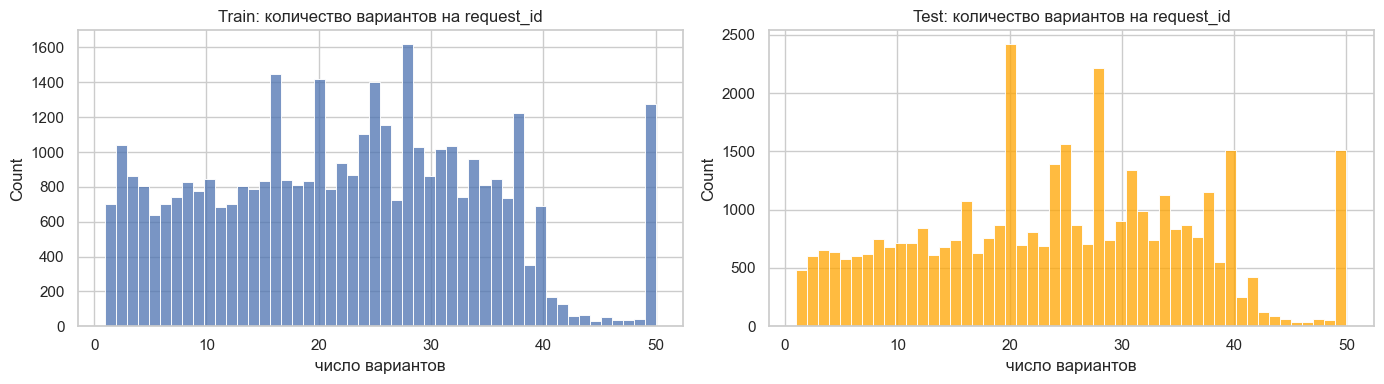

In [8]:
print("Доля позитивов (is_deal=1) в train:", df_train[TARGET].mean())
print("Абсолютное число позитивов:", int(df_train[TARGET].sum()))

pos_per_req = df_train.groupby(REQUEST_ID)[TARGET].sum()
variants_per_req = df_train.groupby(REQUEST_ID).size()

print("\nКоличество позитивов на запрос (train):")
print(pos_per_req.value_counts().sort_index().to_string())

print("\nЧисло вариантов на запрос (train):")
print(variants_per_req.describe().to_string())

print("\nЧисло вариантов на запрос (test):")
print(df_test.groupby(REQUEST_ID).size().describe().to_string())

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.histplot(variants_per_req, bins=50, ax=axes[0])
axes[0].set_title("Train: количество вариантов на request_id")
axes[0].set_xlabel("число вариантов")
sns.histplot(df_test.groupby(REQUEST_ID).size(), bins=50, ax=axes[1], color="orange")
axes[1].set_title("Test: количество вариантов на request_id")
axes[1].set_xlabel("число вариантов")
plt.tight_layout()
plt.show()

SUMMARY["target"] = {
    "train_positive_rate": float(df_train[TARGET].mean()),
    "train_positives_total": int(df_train[TARGET].sum()),
    "positives_per_request": pos_per_req.value_counts().sort_index().to_dict(),
    "variants_per_request_train_describe": variants_per_req.describe().to_dict(),
    "variants_per_request_test_describe": df_test.groupby(REQUEST_ID).size().describe().to_dict(),
}

## 6. Идентификаторы: уникальность app_id, request_id

In [9]:
ids_summary = {}
for name, df in [("train", df_train), ("test", df_test)]:
    ids_summary[name] = {
        "n_rows": len(df),
        "n_unique_request_id": df[REQUEST_ID].nunique(),
        "n_unique_app_id": df["app_id"].nunique() if "app_id" in df.columns else None,
        "request_per_app": (
            df.groupby("app_id")[REQUEST_ID].nunique().describe().to_dict()
            if "app_id" in df.columns else None
        ),
    }
    print(f"=== {name} ===")
    for k, v in ids_summary[name].items():
        print(f"  {k}: {v}")
    print()

overlap_apps = set(df_train["app_id"].unique()) & set(df_test["app_id"].unique())
overlap_requests = set(df_train[REQUEST_ID].unique()) & set(df_test[REQUEST_ID].unique())
print(f"Пересечение app_id между train/test: {len(overlap_apps)}")
print(f"Пересечение request_id между train/test: {len(overlap_requests)}")

SUMMARY["ids"] = ids_summary
SUMMARY["overlap"] = {
    "app_id_intersection": len(overlap_apps),
    "request_id_intersection": len(overlap_requests),
}

=== train ===
  n_rows: 845110
  n_unique_request_id: 37891
  n_unique_app_id: 37817
  request_per_app: {'count': 37817.0, 'mean': 1.0019567919189782, 'std': 0.04419292396061851, 'min': 1.0, '25%': 1.0, '50%': 1.0, '75%': 1.0, 'max': 2.0}

=== test ===
  n_rows: 936883
  n_unique_request_id: 38742
  n_unique_app_id: 38694
  request_per_app: {'count': 38694.0, 'mean': 1.0012405024034734, 'std': 0.03519936899454849, 'min': 1.0, '25%': 1.0, '50%': 1.0, '75%': 1.0, 'max': 2.0}

Пересечение app_id между train/test: 76
Пересечение request_id между train/test: 0


## 7. Временной разрез (`date_part`, `request_received`)

 Сравниваем диапазоны дат в train и test. Если test строго в будущем
 относительно train — выбираем time-based валидацию. Если перемешано —
 можно безопасно использовать GroupKFold по `request_id`.

Train date range: 2026-01-01 00:00:00 → 2026-03-14 00:00:00
Test  date range: 2026-01-01 00:00:00 → 2026-03-30 00:00:00
Пересечение дат: True


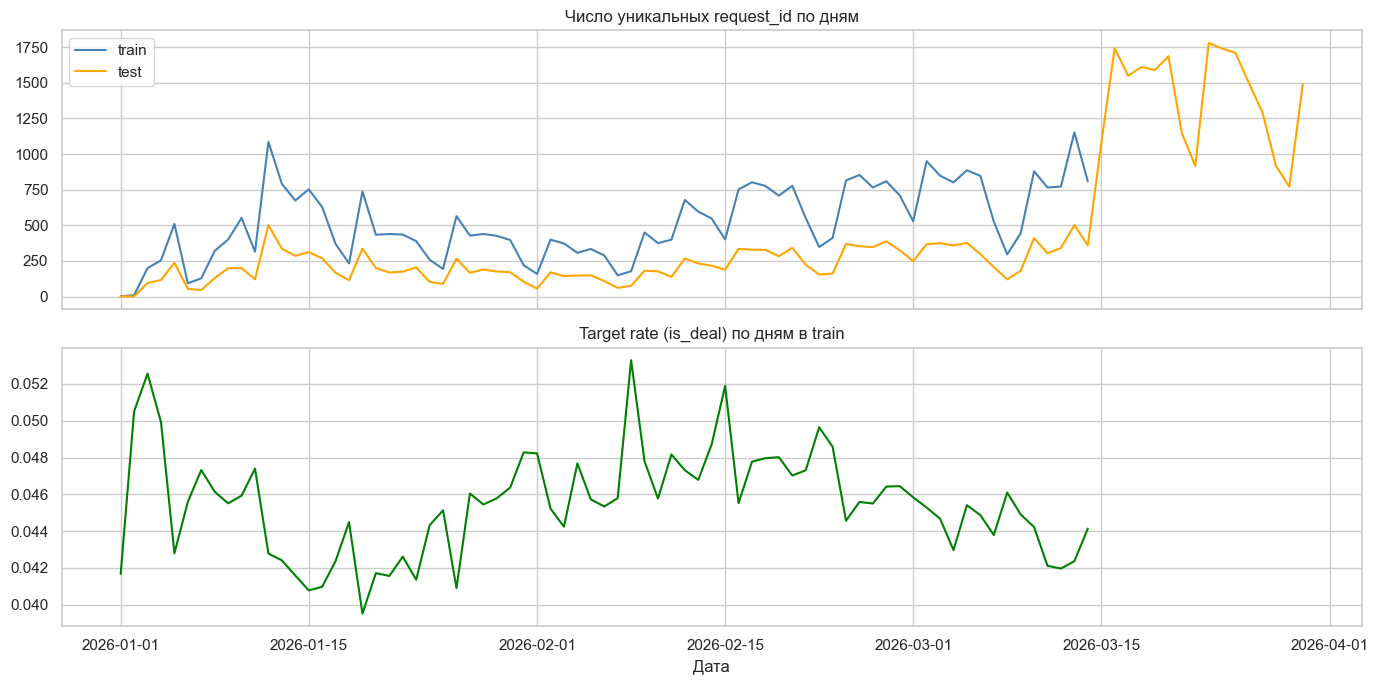


=== ВЫВОД: временной разрез ===
{'train_min': '2026-01-01', 'train_max': '2026-03-14', 'test_min': '2026-01-01', 'test_max': '2026-03-30', 'n_unique_dates_train': 73, 'n_unique_dates_test': 89}


In [10]:
df_train["_date"] = pd.to_datetime(df_train["date_part"])
df_test["_date"] = pd.to_datetime(df_test["date_part"])

print("Train date range:", df_train["_date"].min(), "→", df_train["_date"].max())
print("Test  date range:", df_test["_date"].min(), "→", df_test["_date"].max())
print("Пересечение дат:", df_train["_date"].max() >= df_test["_date"].min()
      and df_test["_date"].max() >= df_train["_date"].min())

train_by_day = df_train.groupby("_date").agg(
    n_rows=(REQUEST_ID, "size"),
    n_requests=(REQUEST_ID, "nunique"),
    target_rate=(TARGET, "mean"),
)
test_by_day = df_test.groupby("_date").agg(
    n_rows=(REQUEST_ID, "size"),
    n_requests=(REQUEST_ID, "nunique"),
)

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)
axes[0].plot(train_by_day.index, train_by_day["n_requests"], label="train", color="steelblue")
axes[0].plot(test_by_day.index, test_by_day["n_requests"], label="test", color="orange")
axes[0].set_title("Число уникальных request_id по дням")
axes[0].legend()
axes[1].plot(train_by_day.index, train_by_day["target_rate"], color="green")
axes[1].set_title("Target rate (is_deal) по дням в train")
axes[1].set_xlabel("Дата")
plt.tight_layout()
plt.show()

SUMMARY["dates"] = {
    "train_min": str(df_train["_date"].min().date()),
    "train_max": str(df_train["_date"].max().date()),
    "test_min": str(df_test["_date"].min().date()),
    "test_max": str(df_test["_date"].max().date()),
    "n_unique_dates_train": int(df_train["_date"].nunique()),
    "n_unique_dates_test": int(df_test["_date"].nunique()),
}
print("\n=== ВЫВОД: временной разрез ===")
print(SUMMARY["dates"])

Распределение по часам суток (train):
_ts
0      8828
1      5178
2      4669
3      4691
4      7303
5     11963
6     17462
7     25427
8     34786
9     47757
10    66158
11    71467
12    71883
13    73915
14    69392
15    62679
16    62407
17    55807
18    44046
19    34613
20    25291
21    19643
22    14139
23     5606

Распределение по дню недели (0=пн..6=вс):
_ts
0    143821
1    130939
2    125565
3    136097
4    141426
5    106676
6     60586


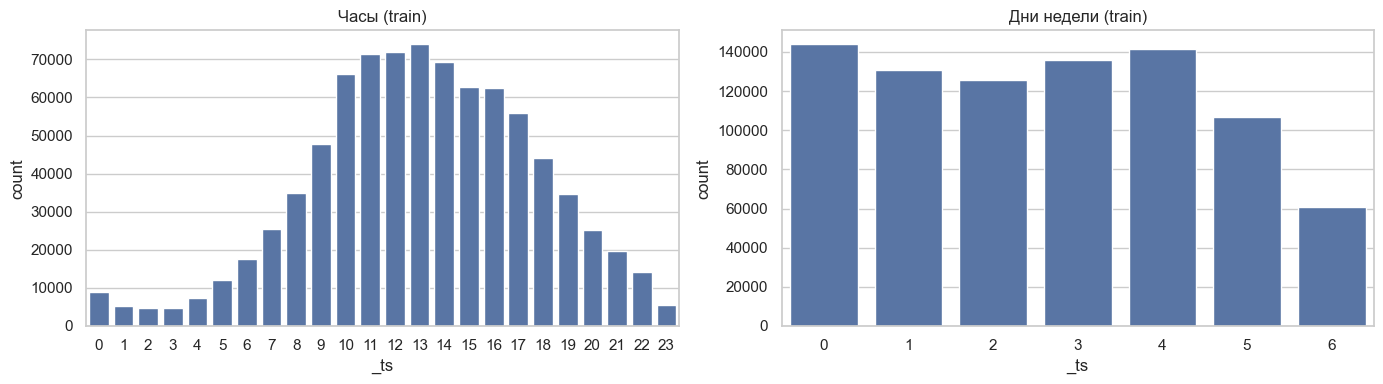

In [11]:
# Часовое распределение запросов (если request_received содержит время)
if "request_received" in df_train.columns:
    df_train["_ts"] = pd.to_datetime(df_train["request_received"], errors="coerce")
    if df_train["_ts"].notna().any():
        hour = df_train["_ts"].dt.hour
        dow = df_train["_ts"].dt.dayofweek
        print("Распределение по часам суток (train):")
        print(hour.value_counts().sort_index().to_string())
        print("\nРаспределение по дню недели (0=пн..6=вс):")
        print(dow.value_counts().sort_index().to_string())

        fig, axes = plt.subplots(1, 2, figsize=(14, 4))
        sns.countplot(x=hour.dropna(), ax=axes[0])
        axes[0].set_title("Часы (train)")
        sns.countplot(x=dow.dropna(), ax=axes[1])
        axes[1].set_title("Дни недели (train)")
        plt.tight_layout()
        plt.show()
    else:
        print("request_received не парсится в datetime — формат нужно посмотреть отдельно")


## 8. Покрытие join'а с features_small.pq

In [12]:
key_cols_features = [c for c in ["app_id", "date_part"] if c in df_features.columns]
print("Ключи features:", key_cols_features)
print("Уникальность ключа в features:",
      df_features[key_cols_features].drop_duplicates().shape[0],
      "из", len(df_features))

if {"app_id", "date_part"}.issubset(df_features.columns):
    train_keys = df_train[["app_id", "date_part"]].drop_duplicates()
    test_keys = df_test[["app_id", "date_part"]].drop_duplicates()
    coverage_train = train_keys.merge(df_features[["app_id", "date_part"]], on=["app_id", "date_part"]).shape[0] / len(train_keys)
    coverage_test = test_keys.merge(df_features[["app_id", "date_part"]], on=["app_id", "date_part"]).shape[0] / len(test_keys)
    print(f"\nПокрытие join train↔features: {coverage_train:.4f}")
    print(f"Покрытие join test↔features:  {coverage_test:.4f}")
    SUMMARY["feature_join_coverage"] = {
        "train": float(coverage_train),
        "test": float(coverage_test),
    }

print("\nКолонки features_small.pq:")
print(df_features.dtypes.to_string())

Ключи features: ['app_id', 'date_part']
Уникальность ключа в features: 76583 из 76583

Покрытие join train↔features: 1.0000
Покрытие join test↔features:  1.0000

Колонки features_small.pq:
app_id                                            object
date_part                                         object
invest_rur_amt                                   float64
clientsegment                                     object
active_claim_flag                                float64
blacklist_employer_flag                          float64
asmart_sub_inactive_days                         float64
primarybank_out_flag                             float64
country                                           object
clienttype                                        object
life_time_days                                   float64
clientgroup                                       object
age                                              float64
tz_msk_timedelta                                 float64
asmart_sub_ac

## 9. Числовые признаки заявки (`req_loan_amount`, `req_term`)

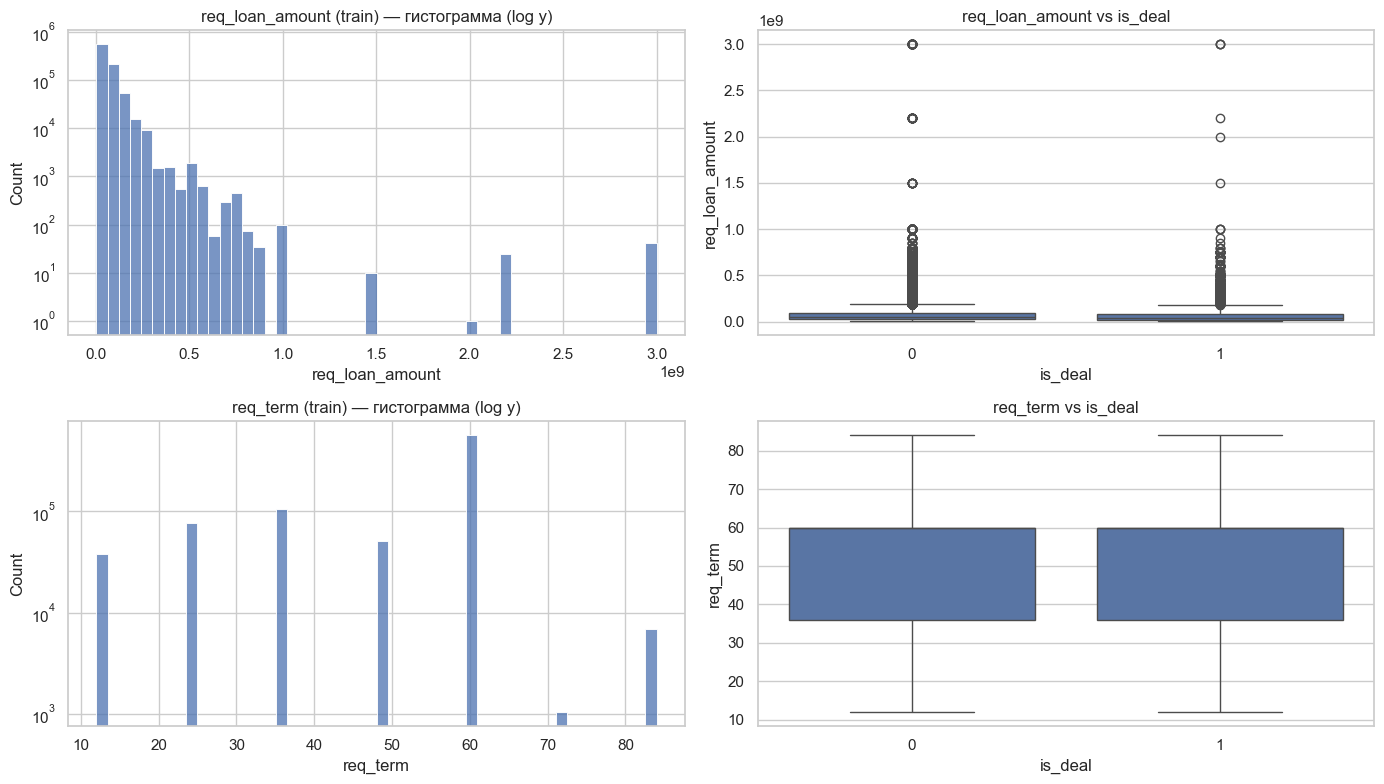

req_loan_amount: train describe
count         845,110.0000
mean       63,620,964.0000
std        68,084,920.0000
min         5,000,000.0000
25%        25,000,000.0000
50%        45,000,000.0000
75%        90,000,000.0000
max     3,000,000,000.0000

req_term: train describe
count   845,110.0000
mean         51.0281
std          15.0758
min          12.0000
25%          36.0000
50%          60.0000
75%          60.0000
max          84.0000



In [13]:
req_features = [c for c in ["req_loan_amount", "req_term"] if c in df_train.columns]
fig, axes = plt.subplots(len(req_features), 2, figsize=(14, 4 * len(req_features)))
if len(req_features) == 1:
    axes = axes.reshape(1, -1)
for i, c in enumerate(req_features):
    series_train = df_train[c].dropna()
    sns.histplot(series_train, bins=50, ax=axes[i, 0], kde=False)
    axes[i, 0].set_title(f"{c} (train) — гистограмма (log y)")
    axes[i, 0].set_yscale("log")
    sns.boxplot(data=df_train, x=TARGET, y=c, ax=axes[i, 1])
    axes[i, 1].set_title(f"{c} vs {TARGET}")
plt.tight_layout()
plt.show()

for c in req_features:
    print(f"{c}: train describe")
    print(df_train[c].describe().to_string())
    print()

## 10. Числовые признаки оффера (`rate`, `term`, `limit`, `eva`, `eva_perc`, `ncl`)

Числовые признаки оффера: ['rate', 'term', 'limit', 'eva', 'eva_perc', 'ncl']


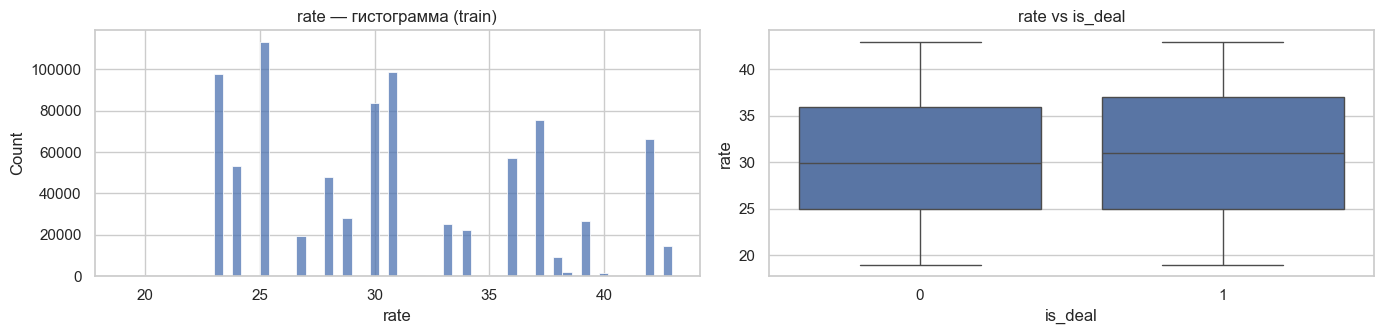

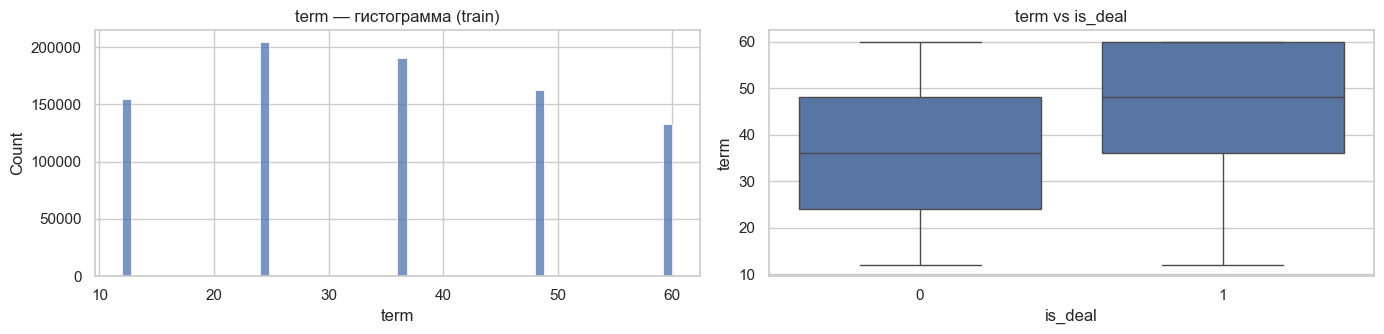

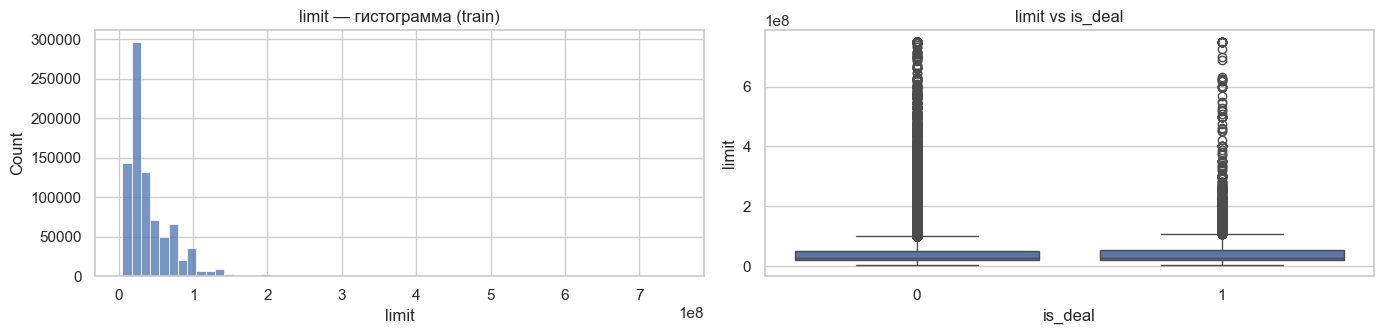

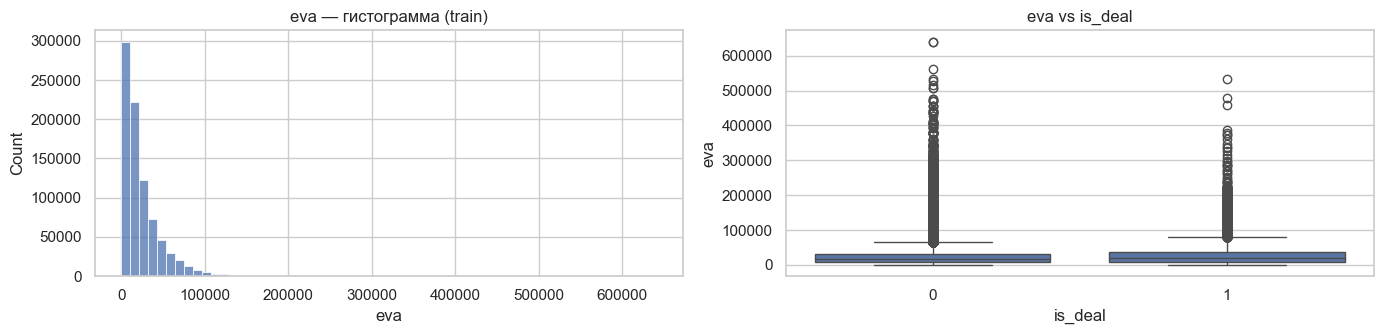

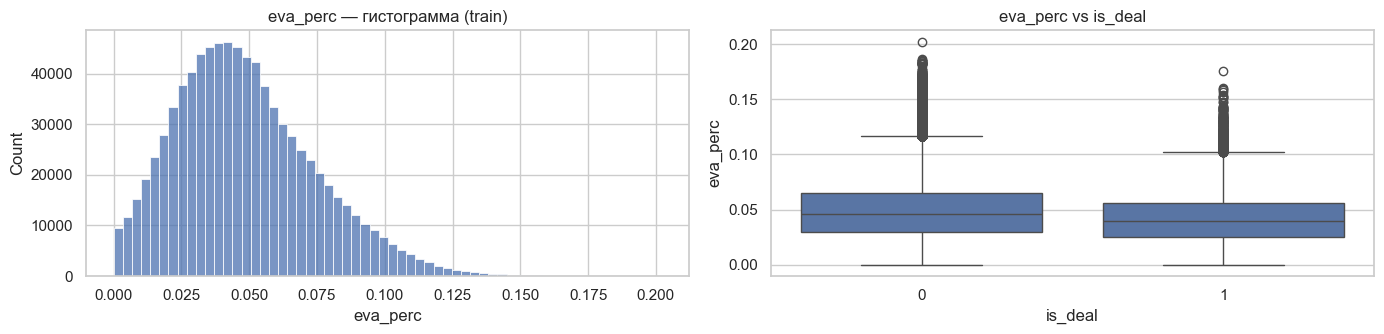

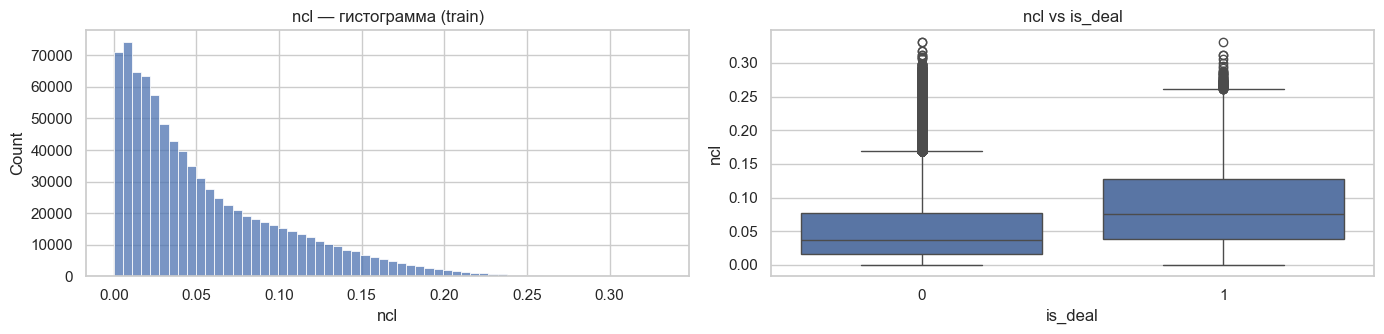

Spearman-корреляция признаков оффера с is_deal:
ncl         0.1276
term        0.1232
rate        0.0408
eva         0.0343
limit      -0.0041
eva_perc   -0.0542


In [14]:
offer_features = [c for c in ["rate", "term", "limit", "eva", "eva_perc", "ncl"] if c in df_train.columns]
print("Числовые признаки оффера:", offer_features)

for c in offer_features:
    fig, axes = plt.subplots(1, 2, figsize=(14, 3.5))
    sns.histplot(df_train[c].dropna(), bins=60, ax=axes[0])
    axes[0].set_title(f"{c} — гистограмма (train)")
    sns.boxplot(data=df_train, x=TARGET, y=c, ax=axes[1])
    axes[1].set_title(f"{c} vs {TARGET}")
    plt.tight_layout()
    plt.show()

# Spearman-корреляция с таргетом
if offer_features:
    spearman = df_train[offer_features + [TARGET]].corr(method="spearman")[TARGET].drop(TARGET)
    print("Spearman-корреляция признаков оффера с is_deal:")
    print(spearman.sort_values(ascending=False).to_string())
    SUMMARY["spearman_with_target_offer"] = spearman.to_dict()

## 11. Категориальные признаки оффера и заявки

Категориальные кандидаты: ['offer_type', 'risk_level_map', 'channel', 'verif_compl', 'verif_need', 'need_2ndfl', 'pil1mtrx_offer']

=== offer_type ===
             mean   count
offer_type               
RA         0.0613  509255
PL         0.0198  335855


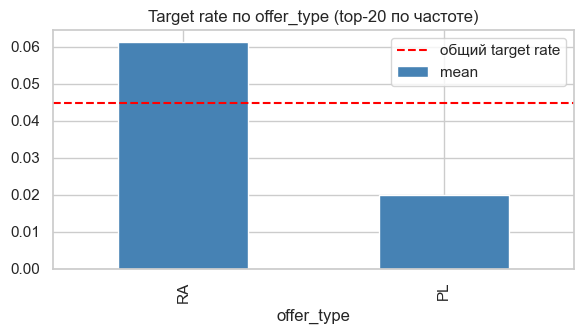


=== risk_level_map ===
                 mean   count
risk_level_map               
VLR            0.0357  378821
LR             0.0462  247500
MR             0.0573  189900
HR             0.0716   28889


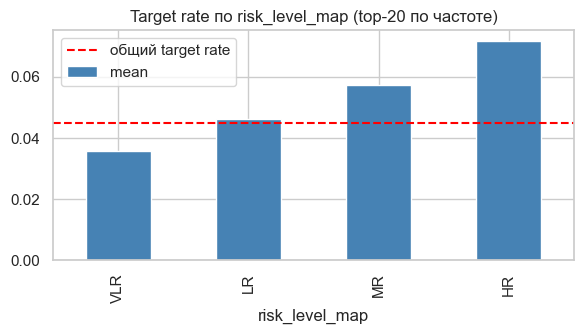


=== channel ===
           mean   count
channel                
Internet 0.0465  668585
Front    0.0386  176525


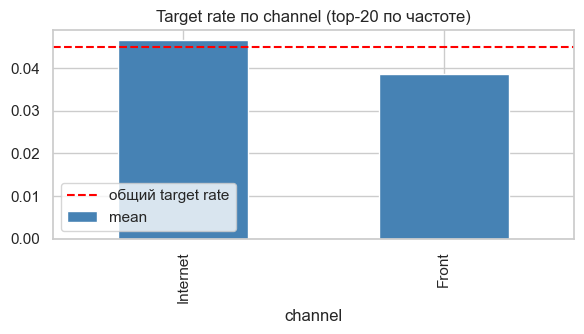


=== verif_compl ===
              mean   count
verif_compl               
N           0.0448  835864
Y           0.0455    9246


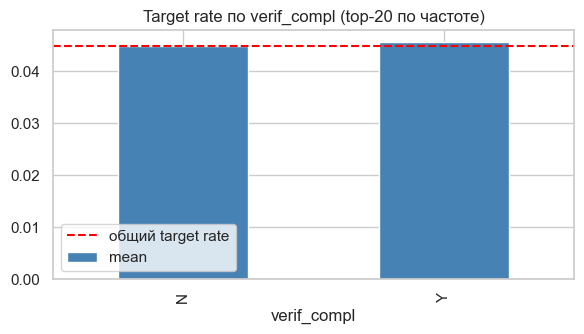


=== verif_need ===
             mean   count
verif_need               
N          0.0449  841103
Y          0.0407    4007


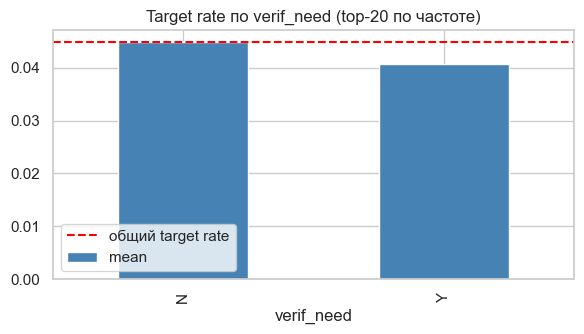


=== need_2ndfl ===
             mean   count
need_2ndfl               
D          0.0430  419476
N          0.0476  415933
Y          0.0026    9701


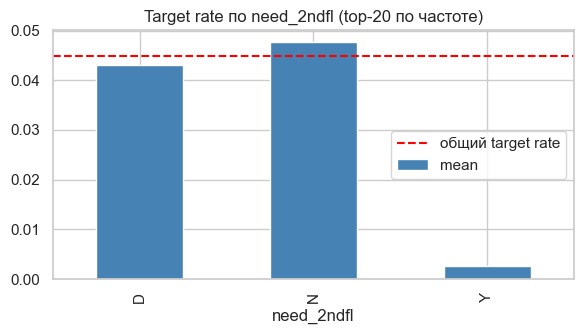


=== pil1mtrx_offer ===
                 mean   count
pil1mtrx_offer               
0              0.0155  819869
1              0.9973   25241


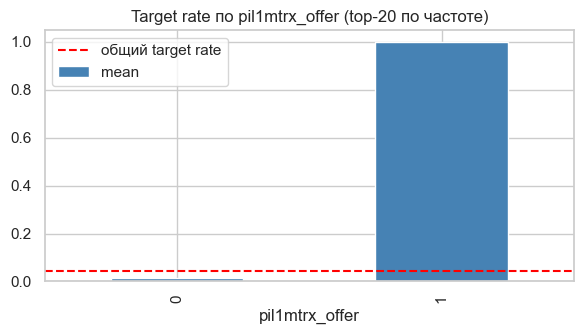

In [15]:
cat_candidates = [
    "offer_type",
    "risk_level_map",
    "channel",
    "verif_compl",
    "verif_need",
    "need_2ndfl",
    "pil1mtrx_offer",
]
cat_features = [c for c in cat_candidates if c in df_train.columns]
print("Категориальные кандидаты:", cat_features)

cat_summary: dict[str, dict] = {}
for c in cat_features:
    vc = df_train[c].value_counts(dropna=False)
    target_by_cat = df_train.groupby(c, dropna=False)[TARGET].agg(["mean", "count"]).sort_values("count", ascending=False)
    print(f"\n=== {c} ===")
    print(target_by_cat.head(20).to_string())
    cat_summary[c] = {
        "n_unique": int(df_train[c].nunique(dropna=False)),
        "top": vc.head(10).to_dict(),
        "target_rate_top": target_by_cat.head(10)["mean"].to_dict(),
    }

    fig, ax = plt.subplots(figsize=(min(14, max(6, vc.shape[0] * 0.4)), 3.5))
    target_by_cat.head(20)["mean"].plot(kind="bar", ax=ax, color="steelblue")
    ax.set_title(f"Target rate по {c} (top-20 по частоте)")
    ax.axhline(df_train[TARGET].mean(), color="red", linestyle="--", label="общий target rate")
    ax.legend()
    plt.tight_layout()
    plt.show()

SUMMARY["categoricals"] = cat_summary

## 12. Анализ `basket_name`

In [16]:
if "basket_name" in df_train.columns:
    sample_values = df_train["basket_name"].dropna().head(10).tolist()
    print("Примеры значений basket_name:")
    for v in sample_values:
        print(f"  type={type(v).__name__}: {v}")
    print(f"\nКардинальность basket_name: {df_train['basket_name'].nunique()}")

Примеры значений basket_name:
  type=str: noverifdocmaxlimit
  type=str: noverifdocmaxlimit
  type=str: noverifdocmaxlimit
  type=str: maxlimit, minannuity, noverifdocmaxlimit
  type=str: noverifdocmaxlimit
  type=str: desiredparams
  type=str: noverifdocmaxlimit
  type=str: desiredparams
  type=str: noverifdocmaxlimit
  type=str: noverifdocmaxlimit

Кардинальность basket_name: 12


## 13. Position bias по `variant_no`

 Ключевой вопрос: есть ли смещение «нумерация → вероятность сделки»?
 Если позитивы концентрируются на маленьких variant_no — модель должна
 учитывать порядок (или мы выводим обратную пропенсити для устранения
 bias).

Описание variant_no в train:
count   845,110.0000
mean         15.0143
std          10.4361
min           1.0000
25%           6.0000
50%          13.0000
75%          22.0000
max          50.0000

Частоты variant_no (top-30):
variant_no
1     37891
2     37188
3     36149
4     35285
5     34482
6     33846
7     33145
8     32403
9     31577
10    30799
11    29956
12    29270
13    28566
14    27760
15    26973
16    26140
17    24695
18    23854
19    23045
20    22214
21    20797
22    20007
23    19068
24    18202
25    17101
26    15698
27    14542
28    13817
29    12200
30    11173


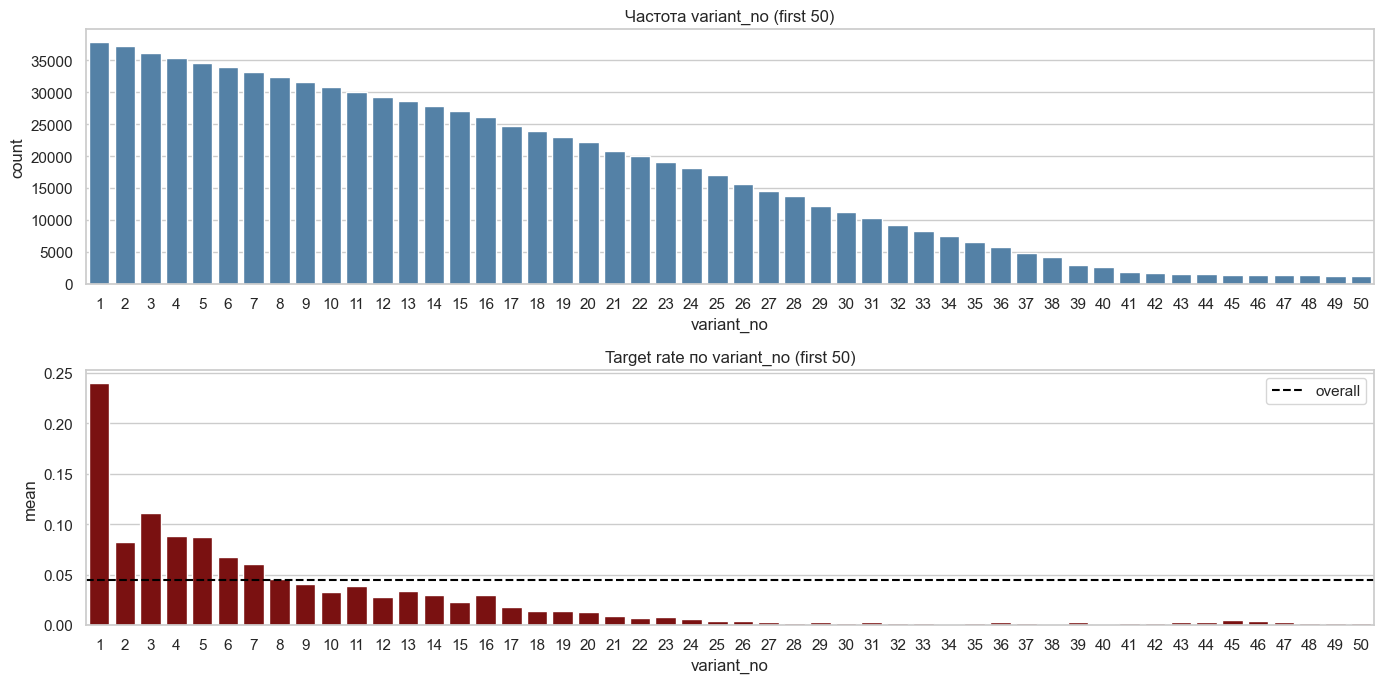

In [17]:
print("Описание variant_no в train:")
print(df_train[VARIANT_ID].describe().to_string())
print("\nЧастоты variant_no (top-30):")
print(df_train[VARIANT_ID].value_counts().sort_index().head(30).to_string())

variant_target = df_train.groupby(VARIANT_ID)[TARGET].agg(["mean", "count"]).reset_index()
variant_target = variant_target.sort_values(VARIANT_ID)

fig, axes = plt.subplots(2, 1, figsize=(14, 7))
sns.barplot(data=variant_target.head(50), x=VARIANT_ID, y="count", ax=axes[0], color="steelblue")
axes[0].set_title("Частота variant_no (first 50)")
sns.barplot(data=variant_target.head(50), x=VARIANT_ID, y="mean", ax=axes[1], color="darkred")
axes[1].axhline(df_train[TARGET].mean(), color="black", linestyle="--", label="overall")
axes[1].set_title("Target rate по variant_no (first 50)")
axes[1].legend()
plt.tight_layout()
plt.show()

SUMMARY["variant_no_target_top10"] = variant_target.head(10).to_dict(orient="records")


## 14. Внутригрупповые паттерны: где находится позитив внутри запроса?

In [18]:
def positive_rank_stats(df: pd.DataFrame, sort_col: str, ascending: bool) -> dict:
    sub = df[[REQUEST_ID, sort_col, TARGET]].copy()
    sub["rank_within_req"] = sub.groupby(REQUEST_ID)[sort_col].rank(method="first", ascending=ascending)
    pos = sub.loc[sub[TARGET] == 1]
    if pos.empty:
        return {}
    return {
        "mean_rank_of_positive": float(pos["rank_within_req"].mean()),
        "median_rank_of_positive": float(pos["rank_within_req"].median()),
        "rank_distribution_top5": pos["rank_within_req"].clip(upper=5).value_counts(normalize=True).sort_index().to_dict(),
    }

for sort_col, ascending in [
    (VARIANT_ID, True),
    ("rate", True),
    ("eva", False),
    ("eva_perc", False),
    ("limit", False),
    ("ncl", True),
]:
    if sort_col in df_train.columns:
        stats = positive_rank_stats(df_train, sort_col, ascending)
        order = "asc" if ascending else "desc"
        print(f"=== {sort_col} ({order}) — где позитив? ===")
        print(stats)
        SUMMARY.setdefault("positive_rank_by", {})[f"{sort_col}_{order}"] = stats
        print()

=== variant_no (asc) — где позитив? ===
{'mean_rank_of_positive': 6.221398221213481, 'median_rank_of_positive': 4.0, 'rank_distribution_top5': {1.0: 0.24037370351798582, 2.0: 0.08038848275316038, 3.0: 0.10617296983452534, 4.0: 0.08244701908104828, 5.0: 0.4906178248132802}}

=== rate (asc) — где позитив? ===
{'mean_rank_of_positive': 11.207991343590827, 'median_rank_of_positive': 9.0, 'rank_distribution_top5': {1.0: 0.0954052413501887, 2.0: 0.07347391201076772, 3.0: 0.06421049853527223, 4.0: 0.05695283840489826, 5.0: 0.7099575096988731}}

=== eva (desc) — где позитив? ===
{'mean_rank_of_positive': 6.9287693647568025, 'median_rank_of_positive': 5.0, 'rank_distribution_top5': {1.0: 0.17692855823282574, 2.0: 0.11076508933519834, 3.0: 0.09614420310891769, 4.0: 0.08561399804702964, 5.0: 0.5305481512760286}}

=== eva_perc (desc) — где позитив? ===
{'mean_rank_of_positive': 13.86579926631654, 'median_rank_of_positive': 12.0, 'rank_distribution_top5': {1.0: 0.08595708743501096, 2.0: 0.052624633

## 15. Корреляции и взаимная информация

 Корреляции считаем только на числовых, MI — на выборке для скорости.

Числовые колонки для корреляций: ['req_loan_amount', 'req_term', 'offer_id', 'variant_no', 'pil1mtrx_offer', 'is_deal', 'term', 'limit']


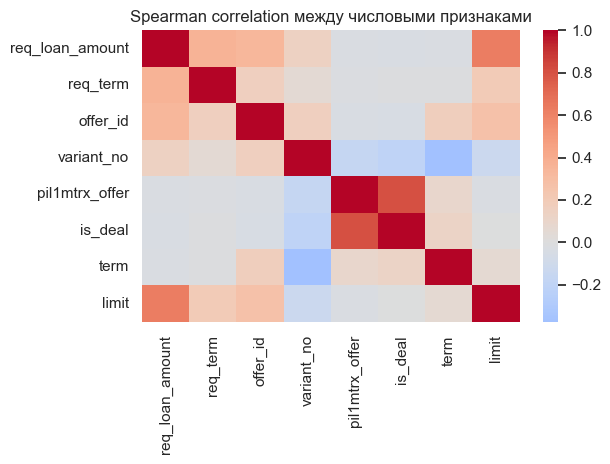


Spearman vs is_deal:
pil1mtrx_offer     0.8076
variant_no        -0.2050
term               0.1232
offer_id          -0.0393
req_loan_amount   -0.0347
req_term          -0.0122
limit             -0.0041


In [20]:
numeric_cols = df_train.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols = [c for c in numeric_cols if c not in {"app_id", REQUEST_ID}]
print("Числовые колонки для корреляций:", numeric_cols)

if numeric_cols:
    corr = df_train[numeric_cols].corr(method="spearman")
    fig, ax = plt.subplots(figsize=(min(14, len(numeric_cols) * 0.8), min(10, len(numeric_cols) * 0.6)))
    sns.heatmap(corr, annot=False, cmap="coolwarm", center=0, ax=ax)
    ax.set_title("Spearman correlation между числовыми признаками")
    plt.tight_layout()
    plt.show()

    cols_for_corr = numeric_cols if TARGET in numeric_cols else numeric_cols + [TARGET]
    spearman_target = df_train[cols_for_corr].corr(method="spearman")[TARGET].drop(TARGET)
    print("\nSpearman vs is_deal:")
    print(spearman_target.reindex(spearman_target.abs().sort_values(ascending=False).index).head(20).to_string())


## 16. Leakage-проверка

 Ищем признаки, аномально сильно связанные с таргетом (R² > 0.5 на
 decision tree depth=1) — это потенциальный leakage. Также проверяем,
 нет ли строк в train, которые точно повторяются в test (по
 идентификаторам).

In [22]:
from sklearn.tree import DecisionTreeClassifier

leakage_report = []
for c in numeric_cols:
    series = df_train[c].fillna(-9999)
    clf = DecisionTreeClassifier(max_depth=1, random_state=42)
    clf.fit(series.to_frame(), df_train[TARGET])
    score = clf.score(series.to_frame(), df_train[TARGET])
    if score > 0.95:
        leakage_report.append((c, score))

print("Подозрительные признаки (accuracy depth=1 > 0.95):")
for row in leakage_report:
    print(" ", row)

# Проверка дубликатов: приводим ключи к строкам, чтобы избежать
# несовпадения dtype между train и test (если есть — это важное наблюдение).
dup_keys = ["app_id", REQUEST_ID, VARIANT_ID]
dup_keys = [k for k in dup_keys if k in df_train.columns and k in df_test.columns]

dtype_mismatch = {k: (str(df_train[k].dtype), str(df_test[k].dtype))
                  for k in dup_keys if df_train[k].dtype != df_test[k].dtype}
if dtype_mismatch:
    print(f"\n⚠ Несовпадение dtype в ключах train vs test: {dtype_mismatch}")

train_keys_df = df_train[dup_keys].drop_duplicates().astype(str)
test_keys_df = df_test[dup_keys].drop_duplicates().astype(str)
common_keys = train_keys_df.merge(test_keys_df, on=dup_keys)
print(f"\nОдинаковых (app_id, request_id, variant_no) в train и test: {len(common_keys)}")
SUMMARY["key_dtype_mismatch_train_vs_test"] = dtype_mismatch
SUMMARY["leakage_suspects"] = [c for c, _ in leakage_report]

Подозрительные признаки (accuracy depth=1 > 0.95):
  ('req_loan_amount', 0.9551644164664955)
  ('req_term', 0.9551644164664955)
  ('offer_id', 0.9551644164664955)
  ('variant_no', 0.9551644164664955)
  ('pil1mtrx_offer', 0.9848729751156654)
  ('is_deal', 1.0)
  ('term', 0.9551644164664955)
  ('limit', 0.9551644164664955)

⚠ Несовпадение dtype в ключах train vs test: {'request_id': ('object', 'int64')}

Одинаковых (app_id, request_id, variant_no) в train и test: 0


## 17. Adversarial validation: насколько train отличим от test

 Обучаем LightGBM (или, при его отсутствии, GradientBoosting) различать
 train (0) и test (1) на общих признаках. AUC ≈ 0.5 — распределения
 совпадают, AUC → 1 — сильный shift.

In [23]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import cross_val_score

shared_numeric = [c for c in numeric_cols if c in df_test.columns]
shared_numeric = [c for c in shared_numeric if c not in {TARGET}]
print("Общие числовые признаки для adversarial validation:", shared_numeric)

sample_train = df_train[shared_numeric].sample(n=min(50_000, len(df_train)), random_state=42)
sample_test = df_test[shared_numeric].sample(n=min(50_000, len(df_test)), random_state=42)

X_adv = pd.concat([sample_train, sample_test], axis=0).fillna(-9999)
y_adv = np.array([0] * len(sample_train) + [1] * len(sample_test))

try:
    import lightgbm as lgb
    model = lgb.LGBMClassifier(n_estimators=200, max_depth=6, random_state=42, verbose=-1)
except ImportError:
    model = GradientBoostingClassifier(n_estimators=100, max_depth=4, random_state=42)

auc_scores = cross_val_score(model, X_adv, y_adv, cv=3, scoring="roc_auc")
print(f"Adversarial AUC: {auc_scores.mean():.4f} ± {auc_scores.std():.4f}")
print("Чем ближе к 0.5 — тем больше train и test похожи.")

SUMMARY["adversarial_auc"] = {
    "mean": float(auc_scores.mean()),
    "std": float(auc_scores.std()),
}

# Если AUC > 0.7 — посмотреть feature importance
if auc_scores.mean() > 0.65 and hasattr(model, "fit"):
    model.fit(X_adv, y_adv)
    if hasattr(model, "feature_importances_"):
        importances = pd.Series(model.feature_importances_, index=shared_numeric)
        print("\nTop признаки, отличающие train от test:")
        print(importances.sort_values(ascending=False).head(15).to_string())
        SUMMARY["adversarial_top_features"] = importances.sort_values(ascending=False).head(15).to_dict()


Общие числовые признаки для adversarial validation: ['req_loan_amount', 'req_term', 'offer_id', 'variant_no', 'pil1mtrx_offer', 'term', 'limit']
Adversarial AUC: 0.5645 ± 0.0006
Чем ближе к 0.5 — тем больше train и test похожи.


## 18. Память и потенциал даункастинга

In [24]:
def downcast_estimate(df: pd.DataFrame, name: str) -> dict:
    before = df.memory_usage(deep=True).sum() / 1024 ** 2
    df2 = df.copy()
    for c in df2.select_dtypes(include=["int64"]).columns:
        df2[c] = pd.to_numeric(df2[c], downcast="integer")
    for c in df2.select_dtypes(include=["float64"]).columns:
        df2[c] = pd.to_numeric(df2[c], downcast="float")
    after = df2.memory_usage(deep=True).sum() / 1024 ** 2
    print(f"{name}: {before:.1f} MB → {after:.1f} MB (экономия {(1 - after / before) * 100:.1f}%)")
    del df2
    return {"before_MB": float(before), "after_MB": float(after)}

SUMMARY["downcast"] = {
    "train": downcast_estimate(df_train, "train"),
    "test": downcast_estimate(df_test, "test"),
    "features": downcast_estimate(df_features, "features"),
}

train: 923.4 MB → 901.6 MB (экономия 2.4%)
test: 921.6 MB → 893.9 MB (экономия 3.0%)
features: 296.6 MB → 254.8 MB (экономия 14.1%)


## 19. Сводка и сохранение `eda_summary.json`

In [37]:
SUMMARY["recommended_cv_scheme"] = (
    "time"
    if (
        SUMMARY["dates"]["train_max"] < SUMMARY["dates"]["test_min"]
        or SUMMARY.get("adversarial_auc", {}).get("mean", 0.5) > 0.7
    )
    else "group"
)

print("=" * 70)
print("СВОДКА EDA:")
print("=" * 70)
print(f"Размеры: {SUMMARY['shapes']}")
print(f"Память: {SUMMARY['memory_MB']}")
print(f"Target rate в train: {SUMMARY['target']['train_positive_rate']:.4f}")
print(f"Позитивов всего: {SUMMARY['target']['positives_total'] if 'positives_total' in SUMMARY['target'] else SUMMARY['target']['train_positives_total']}")
print(f"Позитивов на запрос: {SUMMARY['target']['positives_per_request']}")
print(f"Вариантов на запрос (train, describe): {SUMMARY['target']['variants_per_request_train_describe']}")
print(f"Даты train: {SUMMARY['dates']['train_min']} → {SUMMARY['dates']['train_max']}")
print(f"Даты test:  {SUMMARY['dates']['test_min']} → {SUMMARY['dates']['test_max']}")
print(f"Покрытие join с features: {SUMMARY.get('feature_join_coverage')}")
print(f"Колонок, общих в train/test: см. выше")
print(f"Adversarial AUC: {SUMMARY['adversarial_auc']}")
print(f"Рекомендация по схеме CV: {SUMMARY['recommended_cv_scheme']}")
print(f"Подозрительные на leakage признаки: {SUMMARY['leakage_suspects']}")

OUT_SUMMARY.write_text(json.dumps(SUMMARY, indent=2, ensure_ascii=False, default=str), encoding="utf-8")
print(f"\nСохранено в {OUT_SUMMARY}")

СВОДКА EDA:
Размеры: {'train': [845110, 23], 'test': [936883, 22], 'features': [76583, 280]}
Память: {'train_MB': 910.4670839309692, 'test_MB': 914.4651889801025, 'features_MB': 296.5767822265625}
Target rate в train: 0.0448
Позитивов всего: 37891
Позитивов на запрос: {1: 37891}
Вариантов на запрос (train, describe): {'count': 37891.0, 'mean': 22.303713282837613, 'std': 12.247117787562543, 'min': 1.0, '25%': 13.0, '50%': 23.0, '75%': 31.0, 'max': 50.0}
Даты train: 2026-01-01 → 2026-03-14
Даты test:  2026-01-01 → 2026-03-30
Покрытие join с features: {'train': 1.0, 'test': 1.0}
Колонок, общих в train/test: см. выше
Adversarial AUC: {'mean': 0.5645342320126581, 'std': 0.0006225973614860784}
Рекомендация по схеме CV: group
Подозрительные на leakage признаки: ['req_loan_amount', 'req_term', 'offer_id', 'variant_no', 'pil1mtrx_offer', 'is_deal', 'term', 'limit']

Сохранено в ..\data\eda_summary.json


## 20. Финальные текстовые выводы

In [36]:
print("\n" + "=" * 70)
print("КЛЮЧЕВЫЕ ВЫВОДЫ:")
print("=" * 70)

bullets = [
    f"1. Размеры: train={shapes['train']}, test={shapes['test']}, features={shapes['features']}.",
    f"2. Target rate в train: {SUMMARY['target']['train_positive_rate']:.4f}; позитивов всего: {int(df_train[TARGET].sum())}.",
    f"3. Распределение позитивов на запрос: {SUMMARY['target']['positives_per_request']}.",
    f"4. Среднее число вариантов на request_id (train): {variants_per_req.mean():.2f}, max={int(variants_per_req.max())}.",
    f"5. Временной разрез train: {SUMMARY['dates']['train_min']} → {SUMMARY['dates']['train_max']}.",
    f"6. Временной разрез test : {SUMMARY['dates']['test_min']} → {SUMMARY['dates']['test_max']}.",
    f"7. Пересечение app_id между train и test: {SUMMARY['overlap']['app_id_intersection']}.",
    f"8. Покрытие join с features (train/test): {SUMMARY.get('feature_join_coverage')}.",
    f"9. Колонок, отсутствующих в test: {sorted(set(df_train.columns) - set(df_test.columns))}.",
    f"10. Adversarial AUC: {SUMMARY['adversarial_auc']['mean']:.4f} ± {SUMMARY['adversarial_auc']['std']:.4f}.",
    f"11. Рекомендованная схема CV: {SUMMARY['recommended_cv_scheme']}.",
    f"12. Подозрения на leakage: {SUMMARY['leakage_suspects']}.",
    f"13. Топ-3 признака с наибольшей |Spearman| с is_deal:",
]
print("\n".join(bullets))

if numeric_cols:
    cols_for_corr = numeric_cols if TARGET in numeric_cols else numeric_cols + [TARGET]
    top_spearman = (
        df_train[cols_for_corr].corr(method="spearman")[TARGET]
        .drop(TARGET).abs().sort_values(ascending=False).head(5)
    )
    for c, v in top_spearman.items():
        print(f"    • {c}: |ρ|={v:.4f}")



КЛЮЧЕВЫЕ ВЫВОДЫ:
1. Размеры: train=(845110, 23), test=(936883, 22), features=(76583, 280).
2. Target rate в train: 0.0448; позитивов всего: 37891.
3. Распределение позитивов на запрос: {1: 37891}.
4. Среднее число вариантов на request_id (train): 22.30, max=50.
5. Временной разрез train: 2026-01-01 → 2026-03-14.
6. Временной разрез test : 2026-01-01 → 2026-03-30.
7. Пересечение app_id между train и test: 76.
8. Покрытие join с features (train/test): {'train': 1.0, 'test': 1.0}.
9. Колонок, отсутствующих в test: ['_ts', 'is_deal'].
10. Adversarial AUC: 0.5645 ± 0.0006.
11. Рекомендованная схема CV: group.
12. Подозрения на leakage: ['req_loan_amount', 'req_term', 'offer_id', 'variant_no', 'pil1mtrx_offer', 'is_deal', 'term', 'limit'].
13. Топ-3 признака с наибольшей |Spearman| с is_deal:
    • pil1mtrx_offer: |ρ|=0.8076
    • variant_no: |ρ|=0.2050
    • term: |ρ|=0.1232
    • offer_id: |ρ|=0.0393
    • req_loan_amount: |ρ|=0.0347


## 21. Бейзлайны NDCG@5 без модели

 Метрика на train для нескольких тривиальных стратегий ранжирования.
 Это нижняя планка, ниже которой модель не имеет смысла.
 - **random**: случайный порядок (sanity).
 - **variant_no_asc**: чем меньше `variant_no`, тем выше (баёзовый порядок).
 - **ncl_desc**, **term_desc**, **rate_desc**: по одной фиче.
 - **pil1mtrx_then_variant**: сначала `pil1mtrx_offer=1`, потом по
   `variant_no` — простая эвристика, использующая «золотой» признак.

In [28]:
import sys
sys.path.insert(0, "..")
from alfa_cred.metrics import mean_ndcg_at_5

baselines: dict[str, float] = {}
score_col = "_score_tmp"

def _score(series_score, label):
    df = df_train[[REQUEST_ID, TARGET]].copy()
    df[score_col] = series_score.to_numpy()
    baselines[label] = mean_ndcg_at_5(df, score_col=score_col)

rng = np.random.default_rng(42)
_score(pd.Series(rng.random(len(df_train))), "random")
_score(-df_train[VARIANT_ID], "variant_no_asc")
_score(df_train["ncl"].fillna(-9999), "ncl_desc")
_score(df_train["term"].fillna(-9999), "term_desc")
_score(df_train["rate"].fillna(-9999), "rate_desc")
_score(df_train["eva"].fillna(-9999), "eva_desc")
_score(df_train["pil1mtrx_offer"].astype(float) * 1000 - df_train[VARIANT_ID], "pil1mtrx_then_variant")

print("Бейзлайны NDCG@5 на train (без модели):")
for k, v in sorted(baselines.items(), key=lambda x: -x[1]):
    print(f"  {k:30s} → {v:.4f}")
SUMMARY["heuristic_baselines"] = baselines

Бейзлайны NDCG@5 на train (без модели):
  pil1mtrx_then_variant          → 0.7999
  ncl_desc                       → 0.4609
  variant_no_asc                 → 0.4104
  term_desc                      → 0.3859
  eva_desc                       → 0.3615
  random                         → 0.2188
  rate_desc                      → 0.2037


## 22. Углублённый анализ `pil1mtrx_offer`

 Spearman 0.81 с таргетом — фактически бизнес-метка «оффер согласован».
 Определяем покрытие в train/test и распределение по запросам.

In [29]:
print("=== pil1mtrx_offer в train ===")
print(df_train["pil1mtrx_offer"].value_counts(dropna=False).to_string())

n_total_pos = int(df_train[TARGET].sum())
pil_pos = df_train.loc[df_train["pil1mtrx_offer"] == 1, TARGET]
n_pil_pos = int(pil_pos.sum())
print(f"\npil1mtrx_offer=1: {len(pil_pos):,} оффер-ов, из них {n_pil_pos:,} позитивов "
      f"({n_pil_pos/max(len(pil_pos),1)*100:.2f}%)")
print(f"Покрытие всех позитивов признаком pil1mtrx_offer=1: {n_pil_pos/n_total_pos*100:.2f}%")

req_pil_train = df_train.groupby(REQUEST_ID)["pil1mtrx_offer"].max()
print(f"\nЗапросов train, в которых есть хотя бы один pil1mtrx_offer=1: "
      f"{int((req_pil_train == 1).sum()):,} из {df_train[REQUEST_ID].nunique():,} "
      f"({(req_pil_train == 1).mean()*100:.2f}%)")

multi_pil = df_train.groupby(REQUEST_ID)["pil1mtrx_offer"].sum()
print(f"\nРаспределение числа pil1mtrx_offer=1 на запрос (train):")
print(multi_pil.value_counts().sort_index().to_string())

print("\n=== pil1mtrx_offer в test ===")
print(df_test["pil1mtrx_offer"].value_counts(dropna=False).to_string())
req_pil_test = df_test.groupby(REQUEST_ID)["pil1mtrx_offer"].max()
print(f"Запросов test с хотя бы одним pil1mtrx_offer=1: "
      f"{int((req_pil_test == 1).sum()):,} из {df_test[REQUEST_ID].nunique():,} "
      f"({(req_pil_test == 1).mean()*100:.2f}%)")

SUMMARY["pil1mtrx_analysis"] = {
    "train_offers_pil1": int(len(pil_pos)),
    "train_positives_in_pil1": n_pil_pos,
    "train_share_positives_covered_by_pil1": float(n_pil_pos / n_total_pos),
    "train_requests_with_pil1": int((req_pil_train == 1).sum()),
    "train_share_requests_with_pil1": float((req_pil_train == 1).mean()),
    "test_offers_pil1": int(df_test["pil1mtrx_offer"].sum()),
    "test_requests_with_pil1": int((req_pil_test == 1).sum()),
    "test_share_requests_with_pil1": float((req_pil_test == 1).mean()),
    "multi_pil_per_request_max": int(multi_pil.max()),
}

=== pil1mtrx_offer в train ===
pil1mtrx_offer
0    819869
1     25241

pil1mtrx_offer=1: 25,241 оффер-ов, из них 25,174 позитивов (99.73%)
Покрытие всех позитивов признаком pil1mtrx_offer=1: 66.44%

Запросов train, в которых есть хотя бы один pil1mtrx_offer=1: 25,241 из 37,891 (66.61%)

Распределение числа pil1mtrx_offer=1 на запрос (train):
pil1mtrx_offer
0    12650
1    25241

=== pil1mtrx_offer в test ===
pil1mtrx_offer
0    911544
1     25339
Запросов test с хотя бы одним pil1mtrx_offer=1: 25,339 из 38,742 (65.40%)


## 23. Парсинг `basket_name` (multi-hot бизнес-правила)

 Поле — comma-separated список правил, 12 уникальных. Раскладываем в
 multi-hot и смотрим target rate per токен (только среди заполненных).

In [30]:
if "basket_name" in df_train.columns:
    mask = df_train["basket_name"].notna()
    tokens_per_row = df_train.loc[mask, "basket_name"].str.split(",").apply(
        lambda lst: [x.strip() for x in lst]
    )
    all_tokens = sorted({t for lst in tokens_per_row for t in lst})
    print(f"Уникальные токены basket_name: {all_tokens}")

    rows = []
    target_filled = df_train.loc[mask, TARGET]
    for t in all_tokens:
        flag = tokens_per_row.apply(lambda lst, tok=t: int(tok in lst))
        n = int(flag.sum())
        if n == 0:
            continue
        rate = float(target_filled[flag == 1].mean())
        rows.append({"token": t, "n_offers": n, "target_rate": rate})
    basket_target = pd.DataFrame(rows).sort_values("n_offers", ascending=False)
    print("\nTarget rate по токенам basket_name (среди заполненных):")
    print(basket_target.to_string(index=False))
    SUMMARY["basket_name_tokens"] = basket_target.to_dict(orient="records")


Уникальные токены basket_name: ['desiredparams', 'maxlimit', 'minannuity', 'noverifdocmaxlimit']

Target rate по токенам basket_name (среди заполненных):
             token  n_offers  target_rate
noverifdocmaxlimit     37628       0.2029
     desiredparams      6813       0.4899
          maxlimit      6813       0.2045
        minannuity      6813       0.4924


## 24. Анализ скачка объёма test после 2026-03-14

 На графике плотности видно, что после ~2026-03-14 объём test резко
 увеличивается. Проверяем, есть ли отличия в распределении признаков
 в этих двух эпохах test'а — это поможет точнее имитировать test
 в локальной валидации.

In [31]:
test_dates = pd.to_datetime(df_test["date_part"])
cut_date = pd.Timestamp("2026-03-14")
test_before = df_test[test_dates <= cut_date]
test_after = df_test[test_dates > cut_date]

print(f"Test до {cut_date.date()} (включ.): {len(test_before):,} строк, "
      f"{test_before[REQUEST_ID].nunique():,} запросов")
print(f"Test после {cut_date.date()}: {len(test_after):,} строк, "
      f"{test_after[REQUEST_ID].nunique():,} запросов")

cmp_cols = [c for c in ["variant_no", "rate", "term", "limit",
                         "eva_perc", "ncl", "req_loan_amount",
                         "pil1mtrx_offer"] if c in df_test.columns]
cmp = pd.DataFrame(
    {
        "test_before_mean": [float(test_before[c].mean()) for c in cmp_cols],
        "test_after_mean": [float(test_after[c].mean()) for c in cmp_cols],
    },
    index=cmp_cols,
)
cmp["delta_pct"] = (cmp["test_after_mean"] - cmp["test_before_mean"]) / cmp["test_before_mean"] * 100
print("\nСредние значения признаков в двух эпохах test:")
print(cmp.to_string())

for col in ["offer_type", "channel", "need_2ndfl", "risk_level_map"]:
    if col in df_test.columns:
        before = test_before[col].value_counts(normalize=True).to_dict()
        after = test_after[col].value_counts(normalize=True).to_dict()
        print(f"\n{col}:")
        print(f"  before: {before}")
        print(f"  after : {after}")

SUMMARY["test_epoch_shift"] = {
    "cut_date": str(cut_date.date()),
    "test_before_rows": int(len(test_before)),
    "test_after_rows": int(len(test_after)),
    "feature_means_comparison": cmp.to_dict(),
}

Test до 2026-03-14 (включ.): 361,971 строк, 16,239 запросов
Test после 2026-03-14: 574,912 строк, 22,503 запросов

Средние значения признаков в двух эпохах test:
                 test_before_mean  test_after_mean  delta_pct
variant_no                14.9732          16.0753     7.3603
rate                      30.9155          31.8074     2.8848
term                      34.7027          33.9204    -2.2543
limit             40,363,792.0000  38,542,124.0000    -4.5131
eva_perc                   0.0488           0.0539    10.4013
ncl                        0.0549           0.0484   -11.9334
req_loan_amount   62,786,496.0000  60,562,808.0000    -3.5417
pil1mtrx_offer             0.0297           0.0253   -14.7612

offer_type:
  before: {'RA': 0.6066480463904567, 'PL': 0.3933519536095433}
  after : {'RA': 0.5855974479572525, 'PL': 0.4144025520427474}

channel:
  before: {'Internet': 0.793372949766694, 'Front': 0.206627050233306}
  after : {'Internet': 0.8385579010352889, 'Front': 0.1614420

## 25. `features_small.pq`: заполненность и кандидаты для feature set

 Из 280 колонок многие 90%+ пустые. Фильтруем и определяем список
 числовых/категориальных кандидатов для пайплайна моделирования.


In [32]:
fill_rate = (1 - df_features.isna().mean()).sort_values(ascending=False)
print(f"Распределение заполненности 280 колонок features_small.pq:")
print(fill_rate.describe().to_string())
print(f"\nТоп-30 самых заполненных колонок:")
print(fill_rate.head(30).to_string())

print(f"\nГистограмма заполненности:")
bins = [0, 0.1, 0.3, 0.5, 0.7, 0.8, 0.9, 0.95, 0.99, 1.001]
print(pd.cut(fill_rate, bins=bins, include_lowest=True).value_counts().sort_index().to_string())

candidates_50 = fill_rate[fill_rate >= 0.5].index.tolist()
candidates_80 = fill_rate[fill_rate >= 0.8].index.tolist()
candidates_95 = fill_rate[fill_rate >= 0.95].index.tolist()

num_50 = df_features[candidates_50].select_dtypes(include=[np.number]).columns.tolist()
obj_50 = df_features[candidates_50].select_dtypes(include=["object", "category"]).columns.tolist()
print(f"\n≥50% filled: {len(candidates_50)} (числовых {len(num_50)}, объектных {len(obj_50)})")
print(f"≥80% filled: {len(candidates_80)}")
print(f"≥95% filled: {len(candidates_95)}")

SUMMARY["features_fill_rate"] = {
    "n_total_columns": int(len(fill_rate)),
    "n_filled_50": len(candidates_50),
    "n_filled_80": len(candidates_80),
    "n_filled_95": len(candidates_95),
    "n_numeric_filled_50": len(num_50),
    "n_object_filled_50": len(obj_50),
    "top30_fill_rate": fill_rate.head(30).to_dict(),
}

Распределение заполненности 280 колонок features_small.pq:
count   280.0000
mean      0.6173
std       0.3710
min       0.0000
25%       0.2389
50%       0.8465
75%       0.9586
max       1.0000

Топ-30 самых заполненных колонок:
app_id                          1.0000
date_part                       1.0000
age                             0.9780
izk_in_past_2y                  0.9780
srvpackage_fst_days             0.9780
vip_flag                        0.9780
r200_flag                       0.9780
gender                          0.9780
clientsegment_grace_flag        0.9780
r700_flag                       0.9780
nonresident_flag                0.9780
srvpackage_fst                  0.9780
clientgroup                     0.9780
r800_flag                       0.9780
life_time_days                  0.9780
clienttype                      0.9780
blacklist_employer_flag         0.9780
country                         0.9780
socialparamchange_days          0.9778
clientsegment_new            

## 26. Корреляция клиентских фичей с целью на уровне (`app_id`, `date_part`)

 Фичи клиента не различают офферы внутри запроса — они одинаковы для
 всех вариантов одного запроса. Но они полезны как «глобальная»
 вероятность отклика клиента. Считаем Spearman на агрегированном уровне.

In [33]:
key_cols = ["app_id", "date_part"]
target_by_app = (
    df_train.groupby(key_cols)[TARGET]
    .max()  # =1, если в запросе вообще был позитив (что эквивалентно «1» во всех train-запросах)
    .reset_index()
)
print(f"После агрегации (app_id, date_part): {len(target_by_app):,} строк, "
      f"target_rate={target_by_app[TARGET].mean():.4f}")
# В этой постановке target_by_app — это всегда 1 (т.к. в каждом запросе есть ровно 1 позитив).
# Поэтому полезнее агрегировать на (app_id, date_part) и брать share позитивов или просто
# использовать клиентскую частоту покупки, если в данных есть повторные запросы.
# Поэтому возьмём агрегацию по app_id (без даты) — у клиента может быть несколько запросов:

target_by_client = (
    df_train.groupby("app_id")
    .agg(n_offers=(TARGET, "size"), n_pos=(TARGET, "sum"))
    .reset_index()
)
target_by_client["pos_rate"] = target_by_client["n_pos"] / target_by_client["n_offers"]
print(f"\nКлиентов (app_id) в train: {len(target_by_client):,}")
print(f"Среднее число офферов на клиента: {target_by_client['n_offers'].mean():.2f}")

# Берём только заполненные числовые фичи с fill_rate ≥ 50%
num_feats_for_corr = [c for c in num_50 if c in df_features.columns][:120]
features_subset = df_features[["app_id"] + num_feats_for_corr].drop_duplicates(subset=["app_id"], keep="last")
merged = target_by_client.merge(features_subset, on="app_id", how="inner")
print(f"После merge с features: {len(merged):,} клиентов")

corrs = merged[num_feats_for_corr + ["pos_rate"]].corr(method="spearman")["pos_rate"].drop("pos_rate")
top_corr = corrs.reindex(corrs.abs().sort_values(ascending=False).index).head(30)
print(f"\nТоп-30 числовых клиентских фичей по |Spearman| с pos_rate клиента:")
print(top_corr.to_string())
SUMMARY["client_features_top_spearman"] = top_corr.to_dict()

После агрегации (app_id, date_part): 37,870 строк, target_rate=1.0000

Клиентов (app_id) в train: 37,817
Среднее число офферов на клиента: 22.35
После merge с features: 37,817 клиентов

Топ-30 числовых клиентских фичей по |Spearman| с pos_rate клиента:
hdb_relend_active_max_psk              0.2276
hdb_other_active_max_psk               0.2248
hdb_bki_total_active_products          0.2116
hdb_bki_active_pil_cnt                 0.2065
other_credits_count                    0.2004
hdb_bki_total_products                 0.1974
hdb_bki_last_product_days             -0.1956
hdb_other_active_credits_count         0.1915
hdb_other_credits_count                0.1842
hdb_relend_outstand_sum                0.1827
hdb_bki_active_micro_cnt               0.1802
bki_last_product_days                 -0.1774
hdb_bki_total_cnt                      0.1746
hdb_bki_total_micro_cnt                0.1685
hdb_bki_total_pil_cnt                  0.1668
hdb_bki_total_pil_last_days           -0.1535
hdb_bki_tot

## 27. Финальная пересохранка `eda_summary.json` со всеми разрезами

In [35]:
OUT_SUMMARY.write_text(
    json.dumps(SUMMARY, indent=2, ensure_ascii=False, default=str),
    encoding="utf-8",
)
print(f"Обновлено: {OUT_SUMMARY}")
print(f"Всего ключей в SUMMARY: {len(SUMMARY)}")
print("Ключи:", sorted(SUMMARY.keys()))


Обновлено: ..\data\eda_summary.json
Всего ключей в SUMMARY: 24
Ключи: ['adversarial_auc', 'basket_name_tokens', 'categoricals', 'client_features_top_spearman', 'columns', 'dates', 'downcast', 'feature_join_coverage', 'features_fill_rate', 'heuristic_baselines', 'ids', 'key_dtype_mismatch_train_vs_test', 'leakage_suspects', 'memory_MB', 'missing_top', 'overlap', 'pil1mtrx_analysis', 'positive_rank_by', 'recommended_cv_scheme', 'shapes', 'spearman_with_target_offer', 'target', 'test_epoch_shift', 'variant_no_target_top10']
